In [29]:
import pandas as pd
import ocha_stratus as stratus
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

from src.constants import BENUE_STATE_ADM2_PCODES

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

In [30]:
# Benue state LGA boundaries (used for pcode lookup)
gdf_lga = stratus.codab.load_codab_from_blob("NGA", admin_level=2)
gdf_benue = gdf_lga[gdf_lga["ADM1_EN"] == "Benue"].copy()

# Vulnerability / severity data
df_sev = stratus.load_csv_from_blob(
    "ds-aa-nga-flooding/raw/AA-nigeria_data/OCHA/benue_state_severity.csv"
)
df_sev.head()

,LGA,Total Population,IPC AMN,CH Classification,IDPs,Returnees,Incidents 2025,Fatalities 2025,IHL/HR Outcome,rCSI,HHS,FCS
0,Ushongo,"216,905",1.0,3.0,590,"3,151",1,5,2.0,3.0,4.0,1.0
1,Konshisha,"345,642",1.0,3.0,"13,603","13,871",4,16,2.0,3.0,4.0,1.0
2,Vandeikya,"395,119",1.0,3.0,569,"2,682",1,1,2.0,3.0,4.0,1.0
3,Katsina-Ala,"323,641",1.0,3.0,"16,133","1,950",30,41,3.0,3.0,4.0,1.0
4,Kwande,"305,831",1.0,3.0,"14,148","2,575",20,56,3.0,3.0,4.0,1.0


In [31]:
# Join on LGA name; tag riverine LGAs
df = gdf_benue[["ADM2_EN", "ADM2_PCODE"]].merge(df_sev, left_on="ADM2_EN", right_on="LGA", how="left")

for col in ["IDPs", "Returnees"]:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ""), errors="coerce")

df["is_riverine"] = df["ADM2_PCODE"].isin(BENUE_STATE_ADM2_PCODES)
print(f"Matched: {df['LGA'].notna().sum()} / {len(df)} LGAs")

Matched: 23 / 23 LGAs


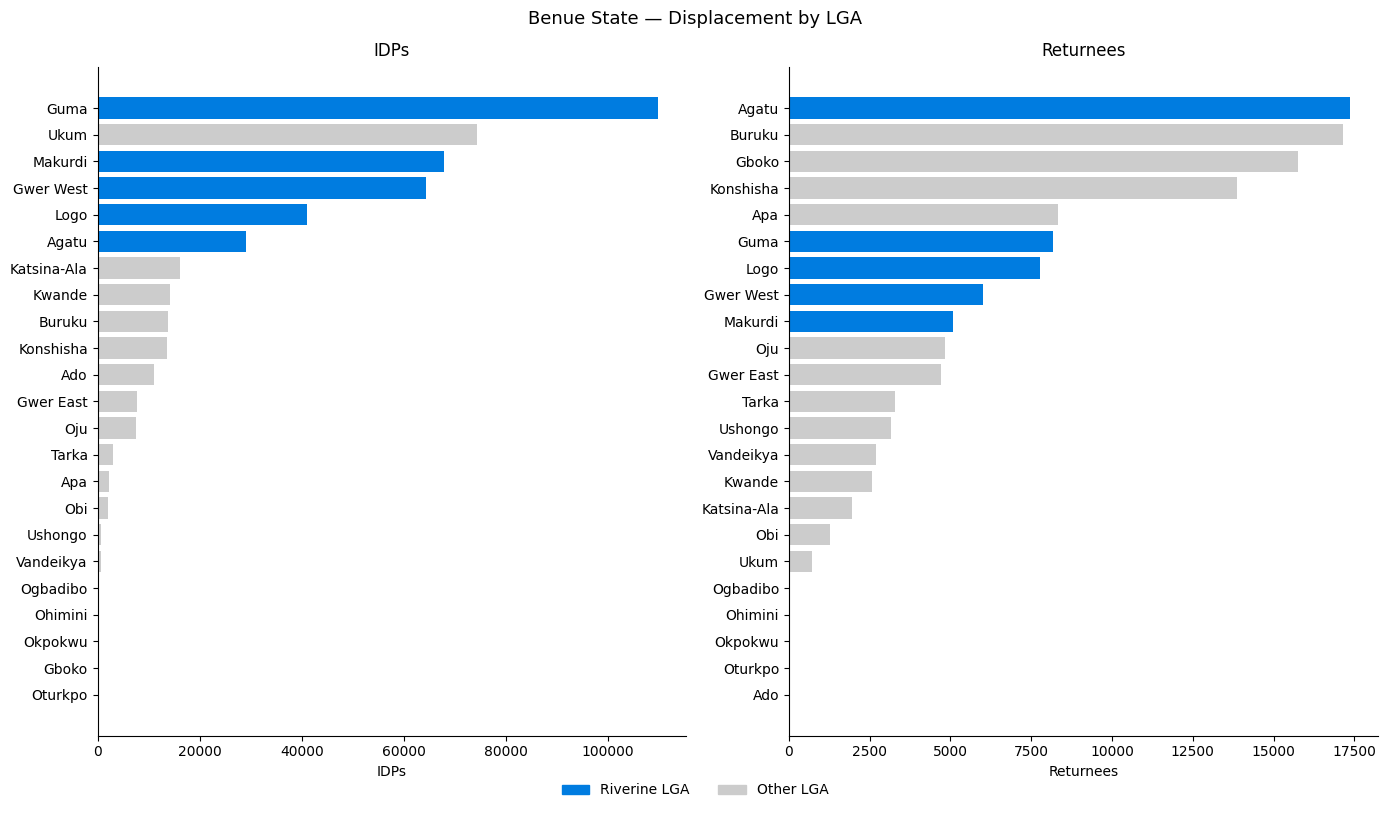

In [32]:
MAP_COLS = ["IDPs", "Returnees"]

fig, axes = plt.subplots(1, len(MAP_COLS), figsize=(7 * len(MAP_COLS), 8), sharey=False)

for ax, col in zip(axes, MAP_COLS):
    df_sorted = df[["ADM2_EN", col, "is_riverine"]].dropna(subset=[col]).sort_values(col, ascending=True)

    colors = df_sorted["is_riverine"].map({True: "#007CE0", False: "#CCCCCC"})
    ax.barh(df_sorted["ADM2_EN"], df_sorted[col], color=colors)

    ax.set_xlabel(col)
    ax.set_title(col, fontsize=12, pad=8)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

legend_handles = [
    Patch(color="#007CE0", label="Riverine LGA"),
    Patch(color="#CCCCCC", label="Other LGA"),
]
fig.legend(handles=legend_handles, loc="lower center", ncol=2, frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.02))

plt.suptitle("Benue State — Displacement by LGA", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "benue_displacement_bars.png", bbox_inches="tight", dpi=150)
plt.show()

In [33]:
# Google inundation history clipped to Benue state
gdf_inundation = stratus.load_geoparquet_from_blob(
    "ds-aa-nga-flooding/processed/google_inundation_history/combined_nga.parquet"
)
gdf_inundation_benue = gpd.clip(gdf_inundation, gdf_benue.union_all())
print(f"Inundation polygons within Benue state: {len(gdf_inundation_benue)}")

# NiHSA at-risk communities — filter to Benue state
df_risk = stratus.load_csv_from_blob(
    "ds-aa-nga-flooding/raw/AA-nigeria_data/NiHSA/AFO_communities_atrisk_2026.csv"
)
df_risk["depth_zone"] = df_risk["depth_zone"].str.strip().str.capitalize()
gdf_risk = gpd.GeoDataFrame(
    df_risk,
    geometry=gpd.points_from_xy(df_risk["lon"], df_risk["lat"]),
    crs=4326,
)
gdf_risk_benue = gdf_risk[gdf_risk.within(gdf_benue.union_all())]
print(f"At-risk communities within Benue state: {len(gdf_risk_benue):,}")

Inundation polygons within Benue state: 3
At-risk communities within Benue state: 424


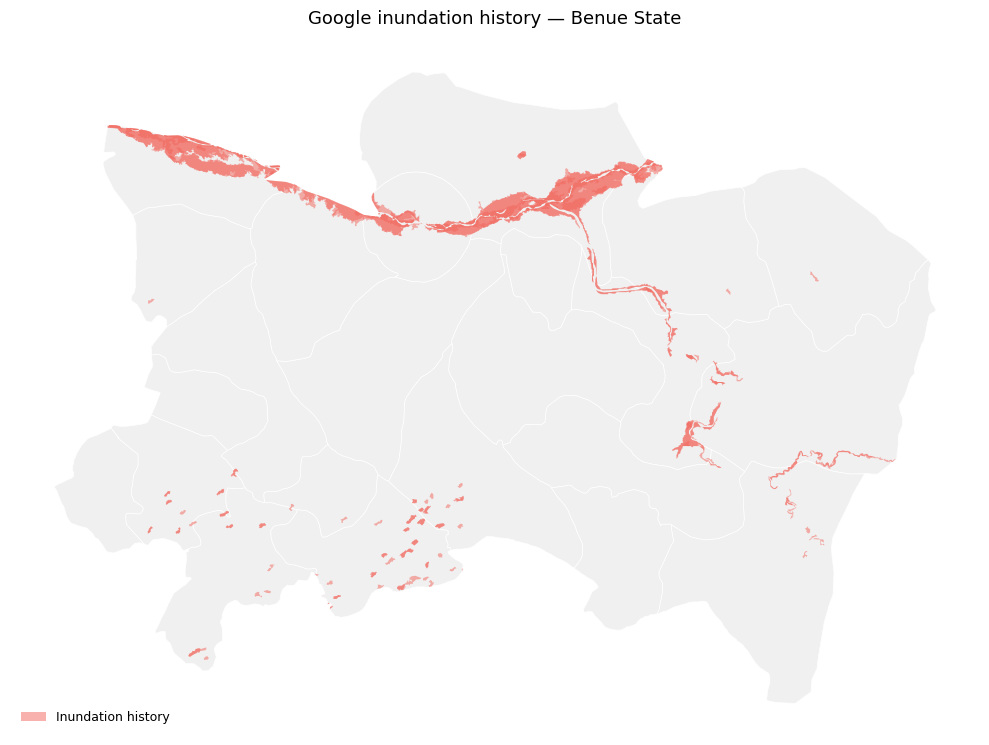

In [34]:
# Map 1: Google inundation history
fig, ax = plt.subplots(figsize=(10, 8))

gdf_benue.plot(ax=ax, color="#F0F0F0", edgecolor="white", linewidth=0.5)
gdf_inundation_benue.plot(ax=ax, facecolor="#F2645A", edgecolor="none", alpha=0.5, zorder=3)

ax.set_axis_off()
ax.set_title("Google inundation history — Benue State", fontsize=13, pad=12)

legend_handles = [Patch(facecolor="#F2645A", alpha=0.5, label="Inundation history")]
ax.legend(handles=legend_handles, frameon=False, fontsize=9, loc="lower left")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "benue_inundation_map.png", bbox_inches="tight", dpi=150)
plt.show()

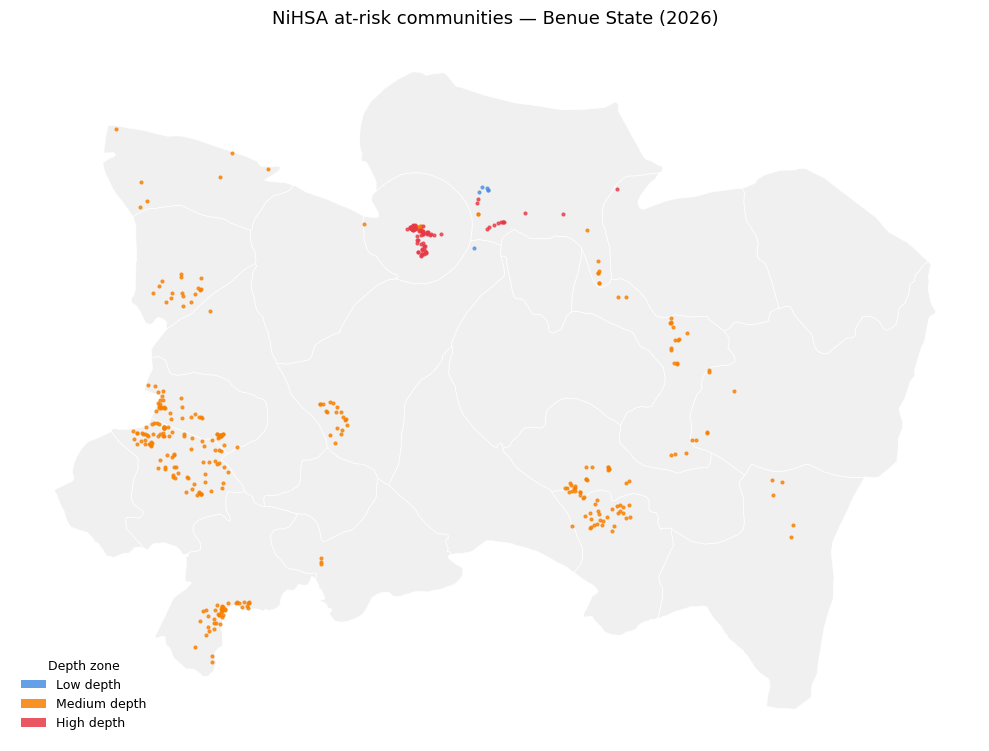

Communities by depth zone:
depth_zone
Low         6
Medium    324
High       94
Name: count, dtype: int64


In [35]:
# Map 2: NiHSA at-risk communities by depth zone
ZONE_ORDER  = ["Low", "Medium", "High"]
ZONE_COLORS = {"Low": "#4A90E2", "Medium": "#F77F00", "High": "#E63946"}

fig, ax = plt.subplots(figsize=(10, 8))

gdf_benue.plot(ax=ax, color="#F0F0F0", edgecolor="white", linewidth=0.5)

for zone in ZONE_ORDER:
    sub = gdf_risk_benue[gdf_risk_benue["depth_zone"] == zone]
    sub.plot(ax=ax, color=ZONE_COLORS[zone], markersize=4, alpha=0.75, zorder=4, label=f"{zone} depth")

ax.set_axis_off()
ax.set_title("NiHSA at-risk communities — Benue State (2026)", fontsize=13, pad=12)
ax.legend(
    handles=[Patch(facecolor=ZONE_COLORS[z], alpha=0.85, label=f"{z} depth") for z in ZONE_ORDER],
    frameon=False, fontsize=9, loc="lower left", title="Depth zone", title_fontsize=9,
)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "benue_risk_communities_map.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Communities by depth zone:\n{gdf_risk_benue['depth_zone'].value_counts().reindex(ZONE_ORDER)}")